In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from scipy.stats import uniform, loguniform, norm
from sklearn.gaussian_process.kernels import Matern, RBF, WhiteKernel, ConstantKernel as C
from sklearn.preprocessing import power_transform
from scipy.optimize import minimize
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_squared_error, r2_score

# **Function 2** - Mystery ML Model

- Model takes two numbers as input and returns a log-likelihood score.

- **Goal** - maximise that score, but each output is noisy, and depending on where you start, you might get stuck in a local optimum.

- **Method of tackling this problem** - Bayesian optimisation, which selects the next inputs based on what it has learned so far.

- I will aim to balance exploration with exploitation, making it well suited to noisy outputs and complex functions with many local peaks.

In [2]:
# Load current cumulative dataset (original + prior weekly updates) for Function 2
X = np.load('/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_2/initial_inputs.npy')
Y = np.load('/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_2/initial_outputs.npy')

# New data for Week 7 (Function 2)
X_w6_new_point = np.array([0.696970, 0.070707], dtype=np.float64)
Y_w6_new_point = np.array([0.4941499168598446], dtype=np.float64)

# Append the new data point
X_updated = np.vstack((X, X_w6_new_point.reshape(1, -1)))

# Remove duplicate X rows (if point already exists)
X_unique, unique_indices = np.unique(X_updated, axis=0, return_index=True)

# Build Y and keep matching rows only
Y_all = np.append(Y, Y_w6_new_point)
Y_updated = Y_all[unique_indices]

# Save updated arrays
np.save('/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_2/initial_inputs.npy', X_unique)
np.save('/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_2/initial_outputs.npy', Y_updated)

# Show updated arrays
print("Updated Inputs (X) - Function 2: ", X_unique)
print("Updated Outputs (Y) - Function 2: ", Y_updated)

Updated Inputs (X) - Function 2:  [[0.14269907 0.34900513]
 [0.33864816 0.21386725]
 [0.34174959 0.02869772]
 [0.43816606 0.68501826]
 [0.45464714 0.29045518]
 [0.57771284 0.77197318]
 [0.638512   0.01429   ]
 [0.66579958 0.12396913]
 [0.688961   0.010598  ]
 [0.69697    0.070707  ]
 [0.70263656 0.9265642 ]
 [0.736899   0.001     ]
 [0.84527543 0.71112027]
 [0.871256   0.999348  ]
 [0.87779099 0.7786275 ]
 [0.998312   0.002851  ]]
Updated Outputs (Y) - Function 2:  [-0.06562362 -0.01385762  0.03874902  0.24461934  0.21496451  0.02310555
  0.29668333  0.53899612  0.55966119  0.49414992  0.61120522  0.37180079
  0.29399291  0.05410069  0.42058624 -0.08088786]


## **Output Analysis**

- Last week (W5) I saw 0.3718, and this week (W6) I saw 0.4941. 
    - This is a meaningful recovery.

- **Real-World Implication**: After the drop from W4 (0.5596) to W5 (0.3718), the W6 query has partially recovered the lost ground. 
    - In log-likelihood terms, we have moved back toward a more probable model configuration
    - However we have not yet surpassed our W4 best of 0.5596, meaning the true peak is still ahead of us.

- The trajectory across the three weeks is: 0.5596 → 0.3718 → 0.4941. 
    - This V-shape pattern strongly suggests we overshot the peak in W5, and W6 has brought us back partway up the correct slope.

- The recovery to 0.4941 is highly informative. 
    - It confirms the likelihood surface is genuinely peaked, there is a real maximum somewhere between the W4 and W6 coordinates, and we are now triangulating toward it from two sides. 

    - The GP now has a much clearer picture of the local curvature: W5 was too far in one direction, W6 has come back but not quite reached the summit. 
    
    - The W4 coordinate at whatever input produced 0.5596

    - 0.5596 remains our best result and the region around it is where the true maximum is most likely to be found.

## **Bayesian Optimisation**: Gaussian Process Regressor

- I am continuing to use a Matern kernel with nu=2.5 plus a WhiteKernel. 
    - The WhiteKernel remains essential to account for the noisy nature of the log-likelihood outputs.

- This week I am also introducing the Output Power Transformation from HEBO (1st place, NeurIPS 2020 BBO Challenge). 
    - Our outputs now span a meaningful range but the distribution across all data points including the initial dataset may still be skewed. 
    
    - Applying a Yeo-Johnson transform before fitting ensures the GP's uncertainty estimates are properly calibrated across the full output range, rather than being distorted by any outliers in the initial dataset.

- I am still Matern 2.5 with WhiteKernel as it has been correctly characterising this noisy surface and the V-shape recovery validates that the model is working. 
    - The power transformation is an additive improvement that makes the GP's internal predictions more reliable without changing the fundamental approach. 
    - I am not changing what is working; I am making it work better.

In [3]:
# Output Power Transformation (HEBO)
Y_transformed = power_transform(
    Y_updated.reshape(-1, 1),
    method='yeo-johnson'
).ravel()

print("Original Y:", Y_updated)
print("Transformed Y:", Y_transformed)

# Define the model - Maintaining Matern 2.5 + WhiteKernel for noisy log-likelihood surface
kernel = Matern(length_scale=1.0,
                length_scale_bounds=(1e-2, 1e2),
                nu=2.5) + \
         WhiteKernel(noise_level=1e-5)

model = GaussianProcessRegressor(
    kernel=kernel,
    n_restarts_optimizer=10,
    normalize_y=False)

model.fit(X_unique, Y_transformed)

Original Y: [-0.06562362 -0.01385762  0.03874902  0.24461934  0.21496451  0.02310555
  0.29668333  0.53899612  0.55966119  0.49414992  0.61120522  0.37180079
  0.29399291  0.05410069  0.42058624 -0.08088786]
Transformed Y: [-1.42716038 -1.17227972 -0.91929293  0.01821347 -0.11216527 -0.99389365
  0.24369989  1.24222423  1.32390394  1.06320971  1.5254878   0.56180315
  0.23215123 -0.84658544  0.76410969 -1.50342571]


,"kernel kernel: kernel instance, default=NoneThe kernel specifying the covariance function of the GP. If None ispassed, the kernel ``ConstantKernel(1.0, constant_value_bounds=""fixed"")* RBF(1.0, length_scale_bounds=""fixed"")`` is used as default. Note thatthe kernel hyperparameters are optimized during fitting unless thebounds are marked as ""fixed"".",Matern(length...e_level=1e-05)
,"alpha alpha: float or ndarray of shape (n_samples,), default=1e-10Value added to the diagonal of the kernel matrix during fitting.This can prevent a potential numerical issue during fitting, byensuring that the calculated values form a positive definite matrix.It can also be interpreted as the variance of additional Gaussianmeasurement noise on the training observations. Note that this isdifferent from using a `WhiteKernel`. If an array is passed, it musthave the same number of entries as the data used for fitting and isused as datapoint-dependent noise level. Allowing to specify thenoise level directly as a parameter is mainly for convenience andfor consistency with :class:`~sklearn.linear_model.Ridge`.For an example illustrating how the alpha parameter controlsthe noise variance in Gaussian Process Regression, see:ref:`sphx_glr_auto_examples_gaussian_process_plot_gpr_noisy_targets.py`.",1e-10
,"optimizer optimizer: ""fmin_l_bfgs_b"", callable or None, default=""fmin_l_bfgs_b""Can either be one of the internally supported optimizers for optimizingthe kernel's parameters, specified by a string, or an externallydefined optimizer passed as a callable. If a callable is passed, itmust have the signature:: def optimizer(obj_func, initial_theta, bounds): # * 'obj_func': the objective function to be minimized, which # takes the hyperparameters theta as a parameter and an # optional flag eval_gradient, which determines if the # gradient is returned additionally to the function value # * 'initial_theta': the initial value for theta, which can be # used by local optimizers # * 'bounds': the bounds on the values of theta .... # Returned are the best found hyperparameters theta and # the corresponding value of the target function. return theta_opt, func_minPer default, the L-BFGS-B algorithm from `scipy.optimize.minimize`is used. If None is passed, the kernel's parameters are kept fixed.Available internal optimizers are: `{'fmin_l_bfgs_b'}`.",'fmin_l_bfgs_b'
,"n_restarts_optimizer n_restarts_optimizer: int, default=0The number of restarts of the optimizer for finding the kernel'sparameters which maximize the log-marginal likelihood. The first runof the optimizer is performed from the kernel's initial parameters,the remaining ones (if any) from thetas sampled log-uniform randomlyfrom the space of allowed theta-values. If greater than 0, all boundsmust be finite. Note that `n_restarts_optimizer == 0` implies that onerun is performed.",10
,"normalize_y normalize_y: bool, default=FalseWhether or not to normalize the target values `y` by removing the meanand scaling to unit-variance. This is recommended for cases wherezero-mean, unit-variance priors are used. Note that, in thisimplementation, the normalisation is reversed before the GP predictionsare reported... versionchanged:: 0.23",False
,"copy_X_train copy_X_train: bool, default=TrueIf True, a persistent copy of the training data is stored in theobject. Otherwise, just a reference to the training data is stored,which might cause predictions to change if the data is modifiedexternally.",True
,"n_targets n_targets: int, default=NoneThe number of dimensions of the target values. Used to decide the numberof outputs when sampling from the prior distributions (i.e. calling:meth:`sample_y` before :meth:`fit`). This parameter is ignored once:meth:`fit` has been called... versionadded:: 1.3",None
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation used to initialize the centers.Pass an int for reproducible results across multiple function calls.See :term:`

### **Acquisition Function**

- I am using Upper Confidence Bound (UCB) with $\beta=2.0$

- I am maintaining $\beta=2.0$. 
    - The V-shape recovery pattern across W4, W5, W6 tells me the peak is real and nearby — it is not a mirage. 
        - This means I do not need a high exploration weight; the peak is somewhere in the region we have already partially mapped.

- With $\beta=2.0$ I can get the right balance, enough exploitation pressure to target the known peak region, enough exploration to find the exact summit rather than a shoulder.

- To triangulate the true maximum by using the GP's updated mean function to identify the precise coordinates between W4 and W6 where the log-likelihood score peaks above 0.5596.

In [4]:
def upper_confidence_bound(X, model, beta=2.0):
    mu, sigma = model.predict(X, return_std=True)
    return mu + beta * sigma

eps = 1e-3
n   = 100
axis = np.linspace(eps, 1 - eps, n)
x1, x2 = np.meshgrid(axis, axis, indexing="xy")
x_grid  = np.column_stack([x1.ravel(), x2.ravel()])

# Calculate UCB values using Beta=2.0
ucb_values = upper_confidence_bound(x_grid, model, beta=2.0)

# Select the next query
next_query = x_grid[np.argmax(ucb_values)]
print(f"Strategic Week 7 Query (Function 2): [{next_query[0]:.6f}-{next_query[1]:.6f}]")

Strategic Week 7 Query (Function 2): [0.656253-0.988919]


## **Visualisation** — GP Surrogate Surface
Plotting the surrogate surface to visually confirm the query point is targeting the region between the W4 and W6 anchor points rather than drifting elsewhere.

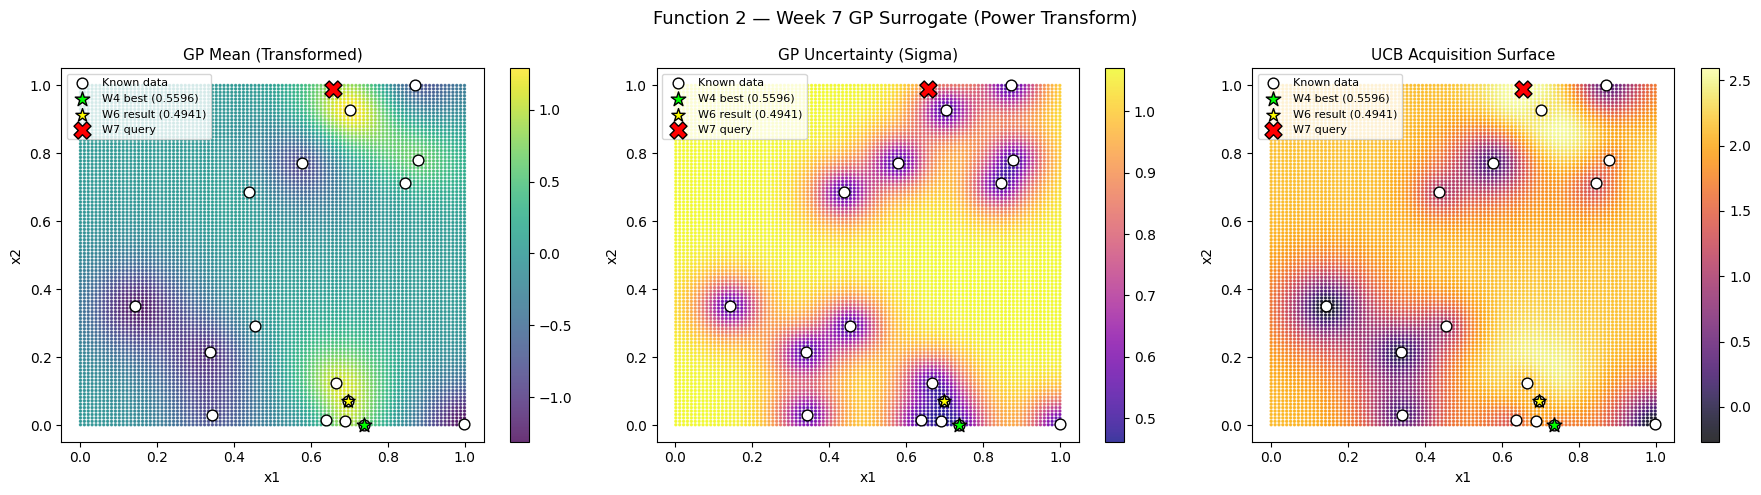

In [5]:
mu_grid, sigma_grid = model.predict(x_grid, return_std=True)
ucb_grid            = mu_grid + 2.0 * sigma_grid

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

titles   = ['GP Mean (Transformed)', 'GP Uncertainty (Sigma)', 'UCB Acquisition Surface']
surfaces = [mu_grid, sigma_grid, ucb_grid]
cmaps    = ['viridis', 'plasma', 'inferno']

for ax, surface, title, cmap in zip(axes, surfaces, titles, cmaps):
    sc = ax.scatter(
        x_grid[:, 0], x_grid[:, 1],
        c=surface, cmap=cmap, s=2, alpha=0.8
    )
    # All known data points
    ax.scatter(X_unique[:, 0], X_unique[:, 1],
               c='white', edgecolors='black', s=60, zorder=5, label='Known data')
    # W4 best result
    w4_best = np.array([[0.736899, 0.001000]])  # approximate W4 coords - update if known exactly
    ax.scatter(w4_best[:, 0], w4_best[:, 1],
               c='lime', edgecolors='black', s=120, zorder=6, marker='*', label='W4 best (0.5596)')
    # W6 recovery point
    w6_point = np.array([[0.696970, 0.070707]])
    ax.scatter(w6_point[:, 0], w6_point[:, 1],
               c='yellow', edgecolors='black', s=100, zorder=6, marker='*', label='W6 result (0.4941)')
    # Next query
    ax.scatter(next_query[0], next_query[1],
               c='red', edgecolors='black', s=150, zorder=7, marker='X', label='W7 query')
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('x1')
    ax.set_ylabel('x2')
    plt.colorbar(sc, ax=ax)
    ax.legend(fontsize=8)

plt.suptitle('Function 2 — Week 7 GP Surrogate (Power Transform)', fontsize=13)
plt.tight_layout()
plt.show()